In [2]:
# 处理高维数据（比如特征数成百上千）时，先跑一遍 PCA 是数据科学界的“标准操作”。再UMAP
# 高维数据中通常包含很多“噪音”或冗余特征。PCA 会优先保留方差最大的主成分（即最重要的信息），舍弃那些微小的波动。

# 如何判断效果好坏

主成分 1 解释度: 12.03%
主成分 2 解释度: 9.56%
总计保留信息量: 21.59%


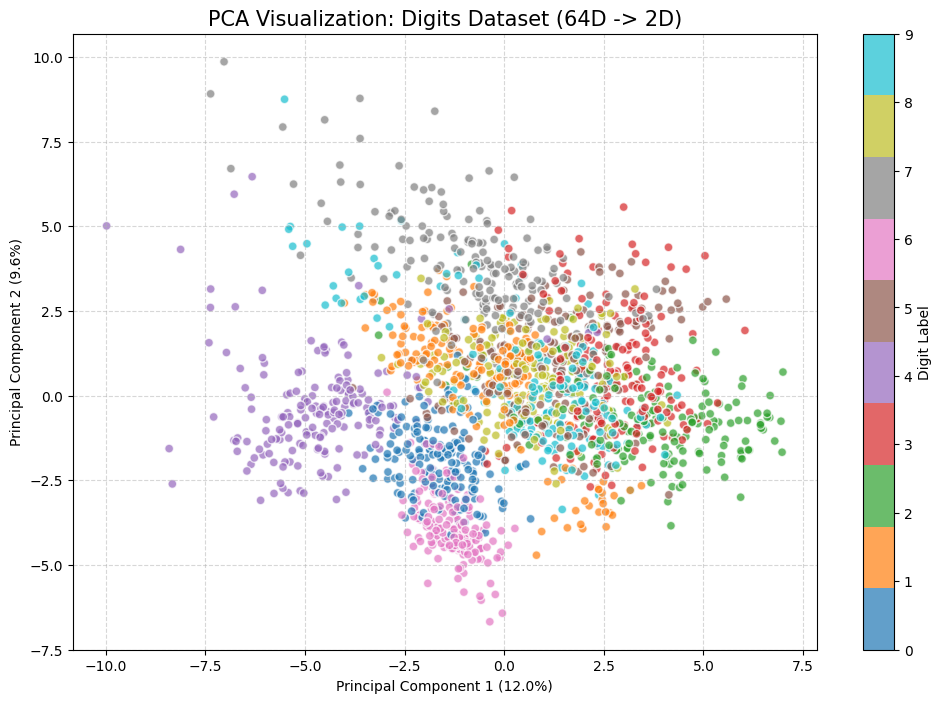

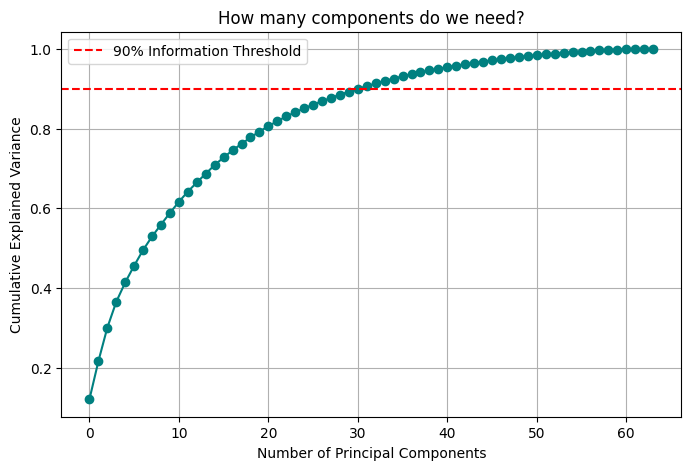

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 加载高维数据集 (手写数字，每个样本 64 维)
digits = load_digits()
X = digits.data
y = digits.target

# 2. 数据标准化 (PCA 的核心前提)
# PCA 受量纲影响很大，必须先将数据缩放到均值为 0，方差为 1
X_scaled = StandardScaler().fit_transform(X)

# 3. 执行 PCA 降维
# 降到 2 维用于平面绘图
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. 计算解释方差比 (Explained Variance Ratio)
# 这告诉我们前两个主成分保留了多少原始信息
exp_var = pca.explained_variance_ratio_
print(f"主成分 1 解释度: {exp_var[0]:.2%}")
print(f"主成分 2 解释度: {exp_var[1]:.2%}")
print(f"总计保留信息量: {sum(exp_var):.2%}")

# 5. 可视化：散点图
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=y, cmap='tab10', alpha=0.7, s=40, edgecolors='white')
# c(color);s(size);edgecolors='white'给点加白边更清晰

# 添加颜色条并对应数字标签
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.title("PCA Visualization: Digits Dataset (64D -> 2D)", fontsize=15)
plt.xlabel(f"Principal Component 1 ({exp_var[0]:.1%})")
plt.ylabel(f"Principal Component 2 ({exp_var[1]:.1%})")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 6. 进阶检查：累积方差贡献率图 (碎石图)
pca_full = PCA().fit(X_scaled) #如果不传参数，默认会计算出与原始特征数一样多的主成分
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='-', color='teal')
# np.cumsum(...) 累积求和
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Information Threshold')
plt.title("How many components do we need?")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\under\anaconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


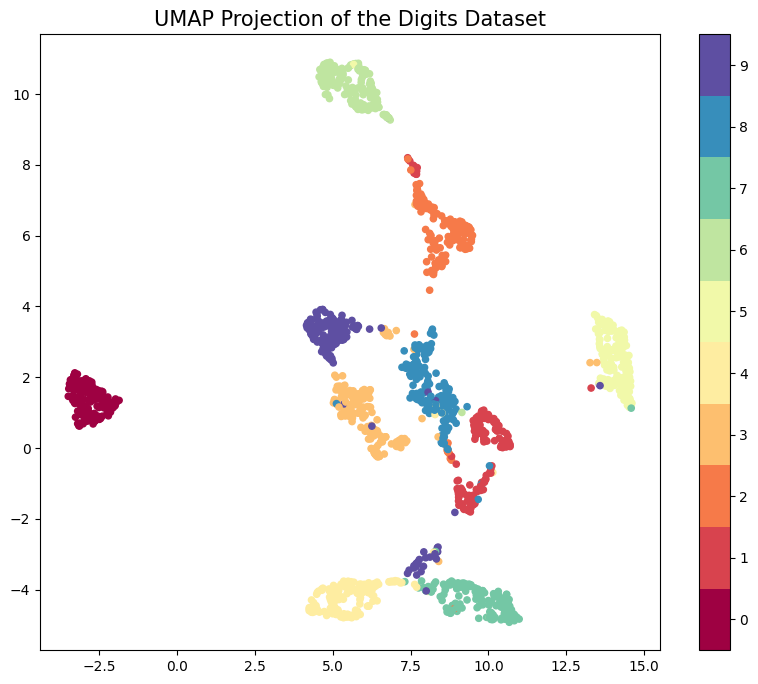

In [ ]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# 1. 准备数据
digits = load_digits()
X_scaled = StandardScaler().fit_transform(digits.data)

# 2. 运行 UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
# n_neighbours：控制局部结构的保留程度，较小值更注重局部细节，较大值更注重全局结构
# min_dist：控制嵌入空间中点之间的最小距离，较小值会产生更紧密的聚类，较大值会产生更分散的嵌入
embedding = reducer.fit_transform(X_scaled)

# 3. 可视化
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=digits.target, cmap='Spectral', s=20)
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(range(10))
plt.title('UMAP Projection of the Digits Dataset', fontsize=15)
plt.show()